# JTBD Analysis — ODI Opportunity Scoring & Segmentation
**Method:** Outcome-Driven Innovation (Ulwick)  
**Sample:** 989 kids, 67 desired outcomes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'hot zone':              '#D85A30',
    'underserved':           '#EF9F27',
    'appropriately served':  '#1D9E75',
    'overserved':            '#378ADD',
    'seg1': '#534AB7',
    'seg2': '#D85A30',
    'seg3': '#1D9E75',
}

print('Libraries loaded.')

Libraries loaded.


## 1. Load data

In [4]:
# ── Update these paths if needed ──
SEGMENTS_FILE   = 'results_segments_forced.csv'         # output of segment_respondents.py
OPP_OVERALL     = 'opportunity_scores.csv' # output of opportunity_scores_calculator.py
OPP_PER_SEG     = 'opp_score_per_segment.csv' # output of opportunity_scores_per_segment.py

df      = pd.read_csv(SEGMENTS_FILE)
opp     = pd.read_csv(OPP_OVERALL)
opp_seg = pd.read_csv(OPP_PER_SEG)

print(f'Respondents : {len(df)}')
print(f'Segments    : {sorted(df.segment.unique())}')
print(f'Outcomes    : {len(opp)}')
df['segment'].value_counts().rename('kids').to_frame()

Respondents : 989
Segments    : [np.int64(1), np.int64(2), np.int64(3)]
Outcomes    : 67


,kids
segment,
3,381
1,368
2,240


## 2. Overall opportunity landscape
All 67 outcomes plotted — importance vs satisfaction. Hot zone = top-left.

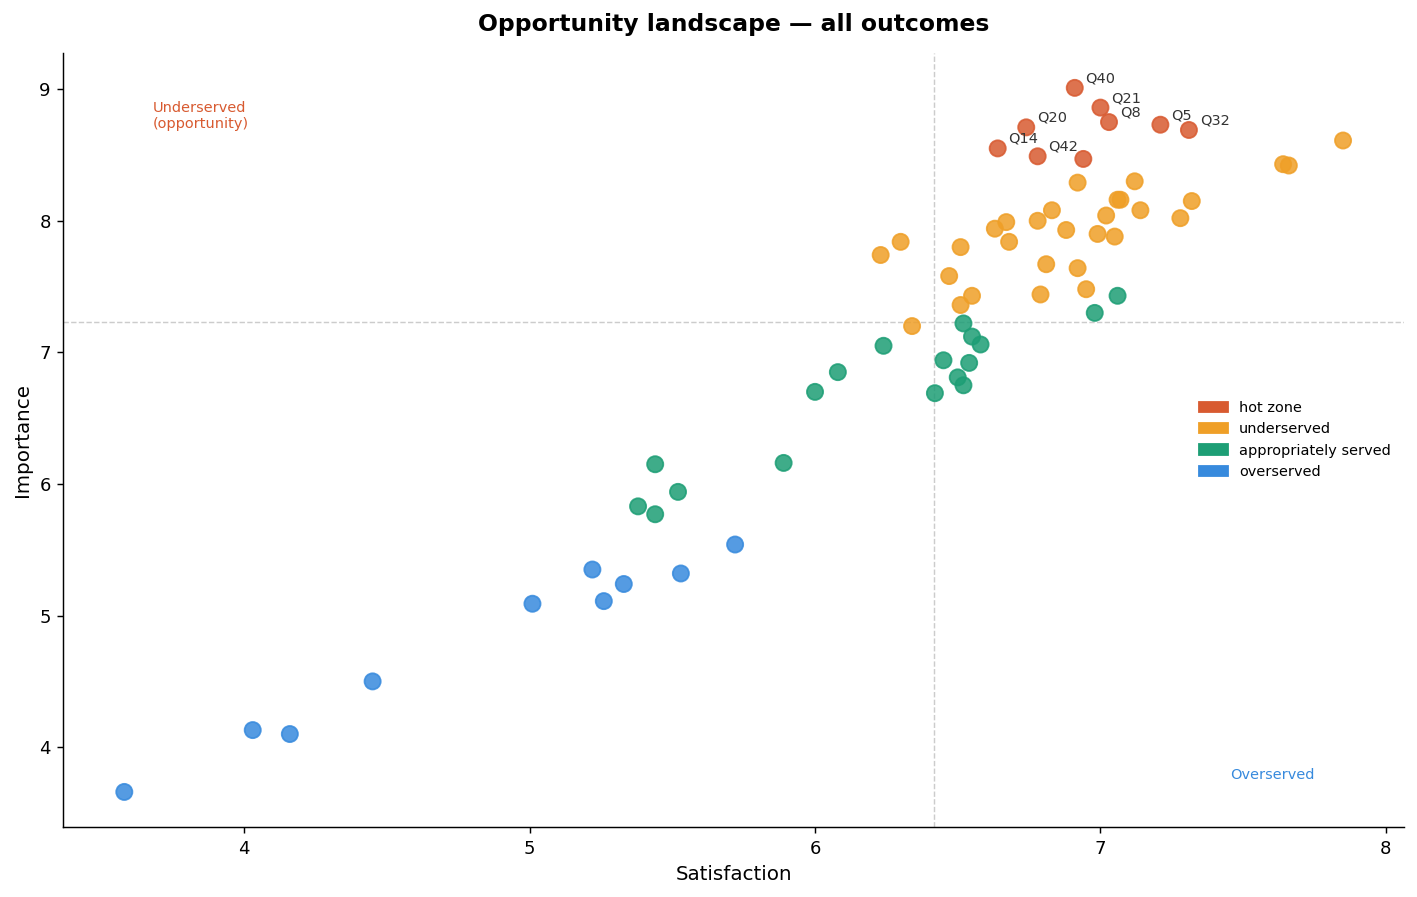

In [5]:
fig, ax = plt.subplots(figsize=(11, 7))

zone_colors = opp['zone'].map(COLORS)
ax.scatter(opp['satisfaction'], opp['importance'],
           c=zone_colors, s=80, alpha=0.85, zorder=3)

# Quadrant lines
ax.axhline(opp['importance'].mean(), color='#ccc', lw=0.8, ls='--')
ax.axvline(opp['satisfaction'].mean(), color='#ccc', lw=0.8, ls='--')

# Label top opportunities
top = opp.nlargest(8, 'opportunity_score')
for _, row in top.iterrows():
    ax.annotate(row['outcome'], (row['satisfaction'], row['importance']),
                textcoords='offset points', xytext=(6, 3), fontsize=8, color='#333')

# Quadrant labels
ax.text(opp['satisfaction'].min() + 0.1, opp['importance'].max() - 0.1,
        'Underserved\n(opportunity)', fontsize=8, color='#D85A30', va='top')
ax.text(opp['satisfaction'].max() - 0.1, opp['importance'].min() + 0.1,
        'Overserved', fontsize=8, color='#378ADD', ha='right')

# Legend
legend = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items() if k in opp['zone'].values]
ax.legend(handles=legend, fontsize=8, frameon=False)

ax.set_xlabel('Satisfaction', fontsize=11)
ax.set_ylabel('Importance', fontsize=11)
ax.set_title('Opportunity landscape — all outcomes', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('landscape_overall.png', bbox_inches='tight')
plt.show()

## 3. Top 15 opportunities — overall

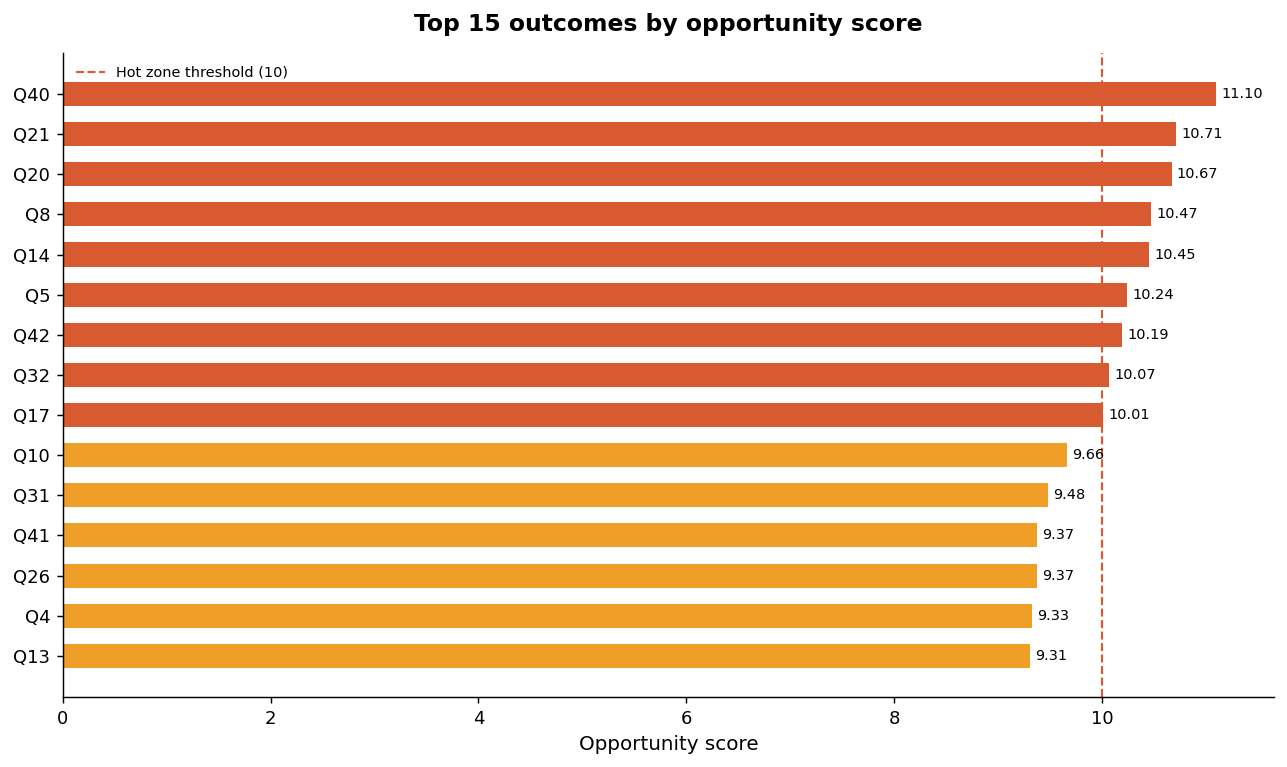

In [6]:
top15 = opp.nlargest(15, 'opportunity_score')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15['outcome'][::-1], top15['opportunity_score'][::-1],
               color=[COLORS[z] for z in top15['zone'][::-1]], height=0.6)

ax.axvline(10, color='#D85A30', lw=1.2, ls='--', label='Hot zone threshold (10)')
ax.set_xlabel('Opportunity score', fontsize=11)
ax.set_title('Top 15 outcomes by opportunity score', fontsize=13, fontweight='bold', pad=12)

for bar, val in zip(bars, top15['opportunity_score'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)

ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig('top15_overall.png', bbox_inches='tight')
plt.show()

## 4. Segment profiles
Who is in each segment?

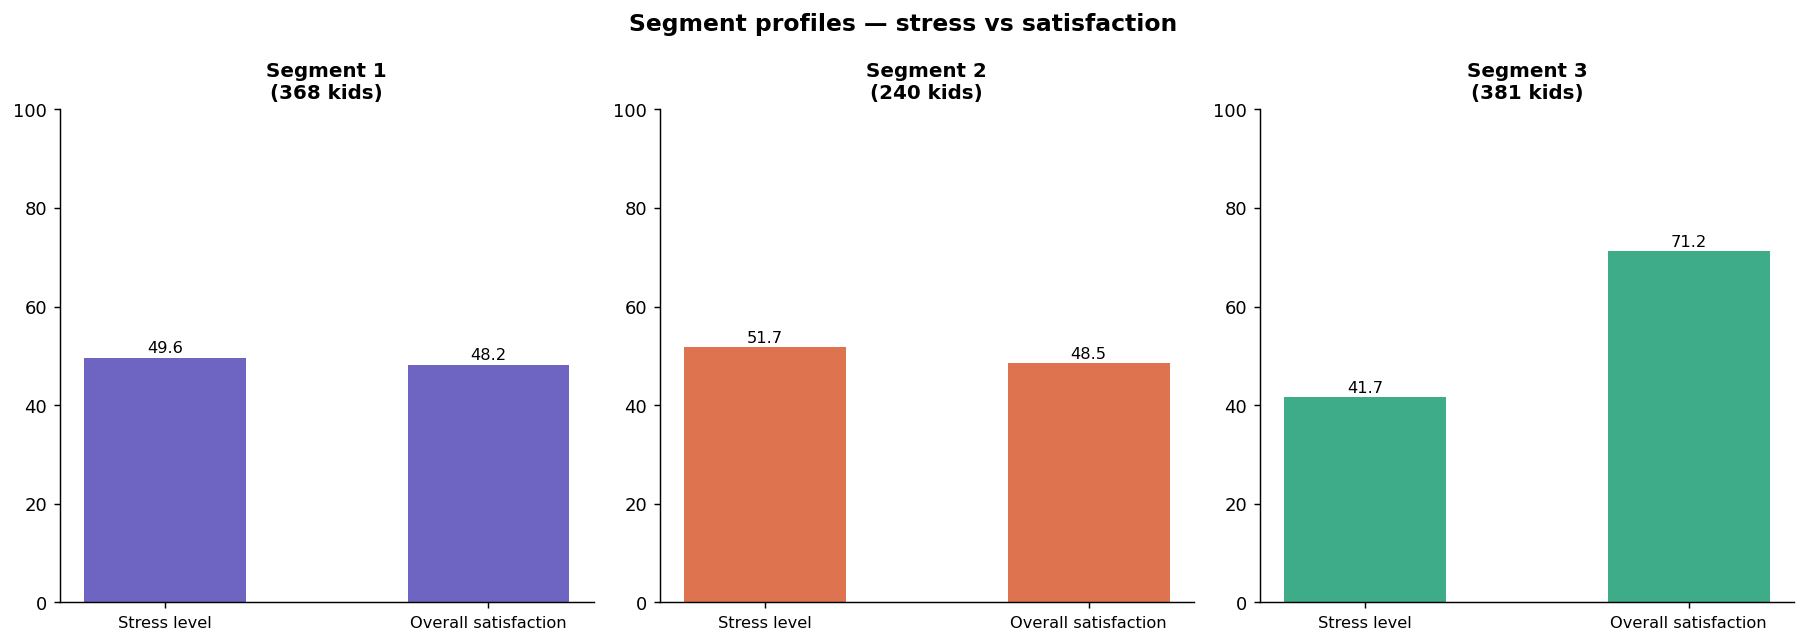

In [7]:
seg_colors = ['#534AB7', '#D85A30', '#1D9E75']
segments   = sorted(df['segment'].unique())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['stress_level', 'overall_satisfaction']
labels  = ['Stress level', 'Overall satisfaction']

for i, seg in enumerate(segments):
    seg_df = df[df['segment'] == seg]
    ax = axes[i]
    vals = [seg_df[m].mean() for m in metrics]
    bars = ax.bar(labels, vals, color=seg_colors[i], alpha=0.85, width=0.5)
    ax.set_ylim(0, 100)
    ax.set_title(f'Segment {seg}\n({len(seg_df)} kids)', fontsize=11, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}', ha='center', fontsize=9)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Segment profiles — stress vs satisfaction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_profiles.png', bbox_inches='tight')
plt.show()

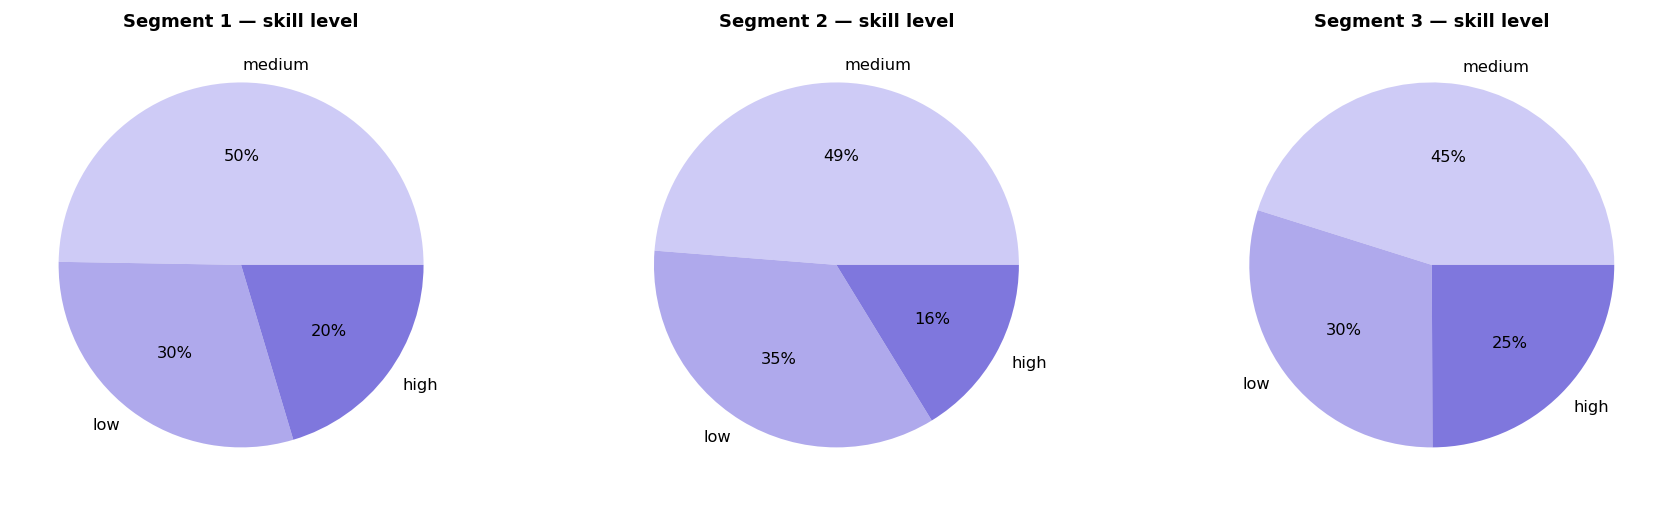

In [8]:
# Skill level distribution per segment
fig, axes = plt.subplots(1, len(segments), figsize=(14, 4))

for i, seg in enumerate(segments):
    seg_df = df[df['segment'] == seg]
    counts = seg_df['skill_level'].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.0f%%',
                colors=['#CECBF6','#AFA9EC','#7F77DD'],
                textprops={'fontsize': 9})
    axes[i].set_title(f'Segment {seg} — skill level', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('segment_skill.png', bbox_inches='tight')
plt.show()

## 5. Opportunity landscape per segment
Each segment gets its own map.

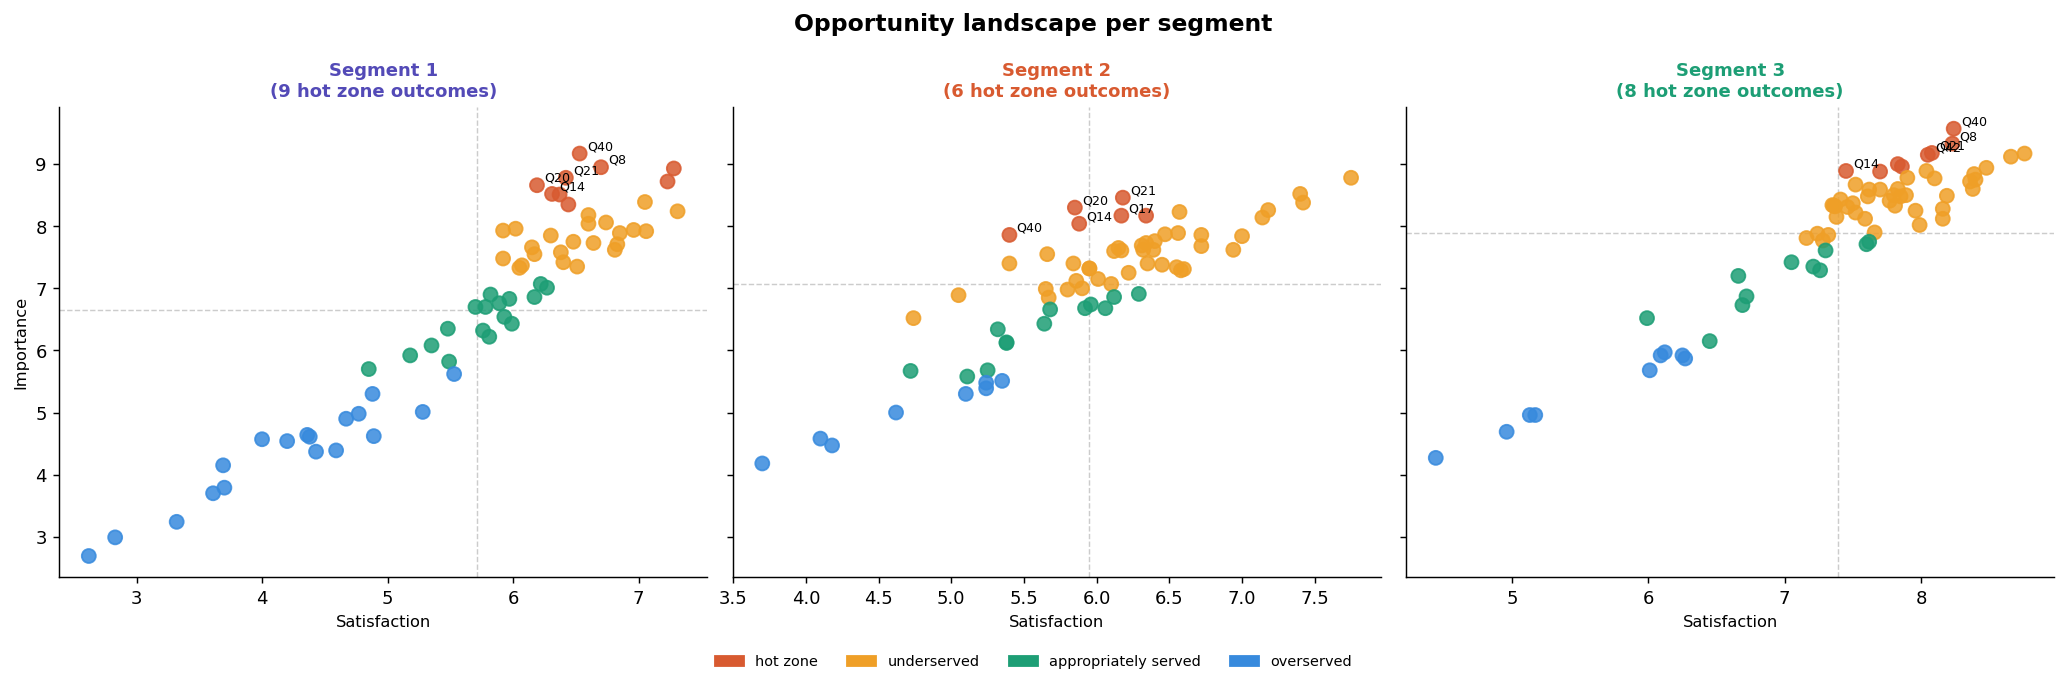

In [9]:
fig, axes = plt.subplots(1, len(segments), figsize=(16, 5), sharey=True)

for i, seg in enumerate(segments):
    seg_opp = opp_seg[opp_seg['segment'] == seg]
    ax = axes[i]

    colors = seg_opp['zone'].map(COLORS)
    ax.scatter(seg_opp['satisfaction'], seg_opp['importance'],
               c=colors, s=60, alpha=0.85, zorder=3)

    ax.axhline(seg_opp['importance'].mean(), color='#ccc', lw=0.8, ls='--')
    ax.axvline(seg_opp['satisfaction'].mean(), color='#ccc', lw=0.8, ls='--')

    # Label top 5
    for _, row in seg_opp.nlargest(5, 'opportunity_score').iterrows():
        ax.annotate(row['outcome'], (row['satisfaction'], row['importance']),
                    textcoords='offset points', xytext=(4, 2), fontsize=7)

    hot_count = len(seg_opp[seg_opp['zone'] == 'hot zone'])
    ax.set_title(f'Segment {seg}\n({hot_count} hot zone outcomes)',
                 fontsize=10, fontweight='bold', color=seg_colors[i])
    ax.set_xlabel('Satisfaction', fontsize=9)
    if i == 0:
        ax.set_ylabel('Importance', fontsize=9)

legend = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()
          if k in opp_seg['zone'].values]
fig.legend(handles=legend, fontsize=8, frameon=False,
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Opportunity landscape per segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('landscape_per_segment.png', bbox_inches='tight')
plt.show()

## 6. Top 10 opportunities per segment — side by side

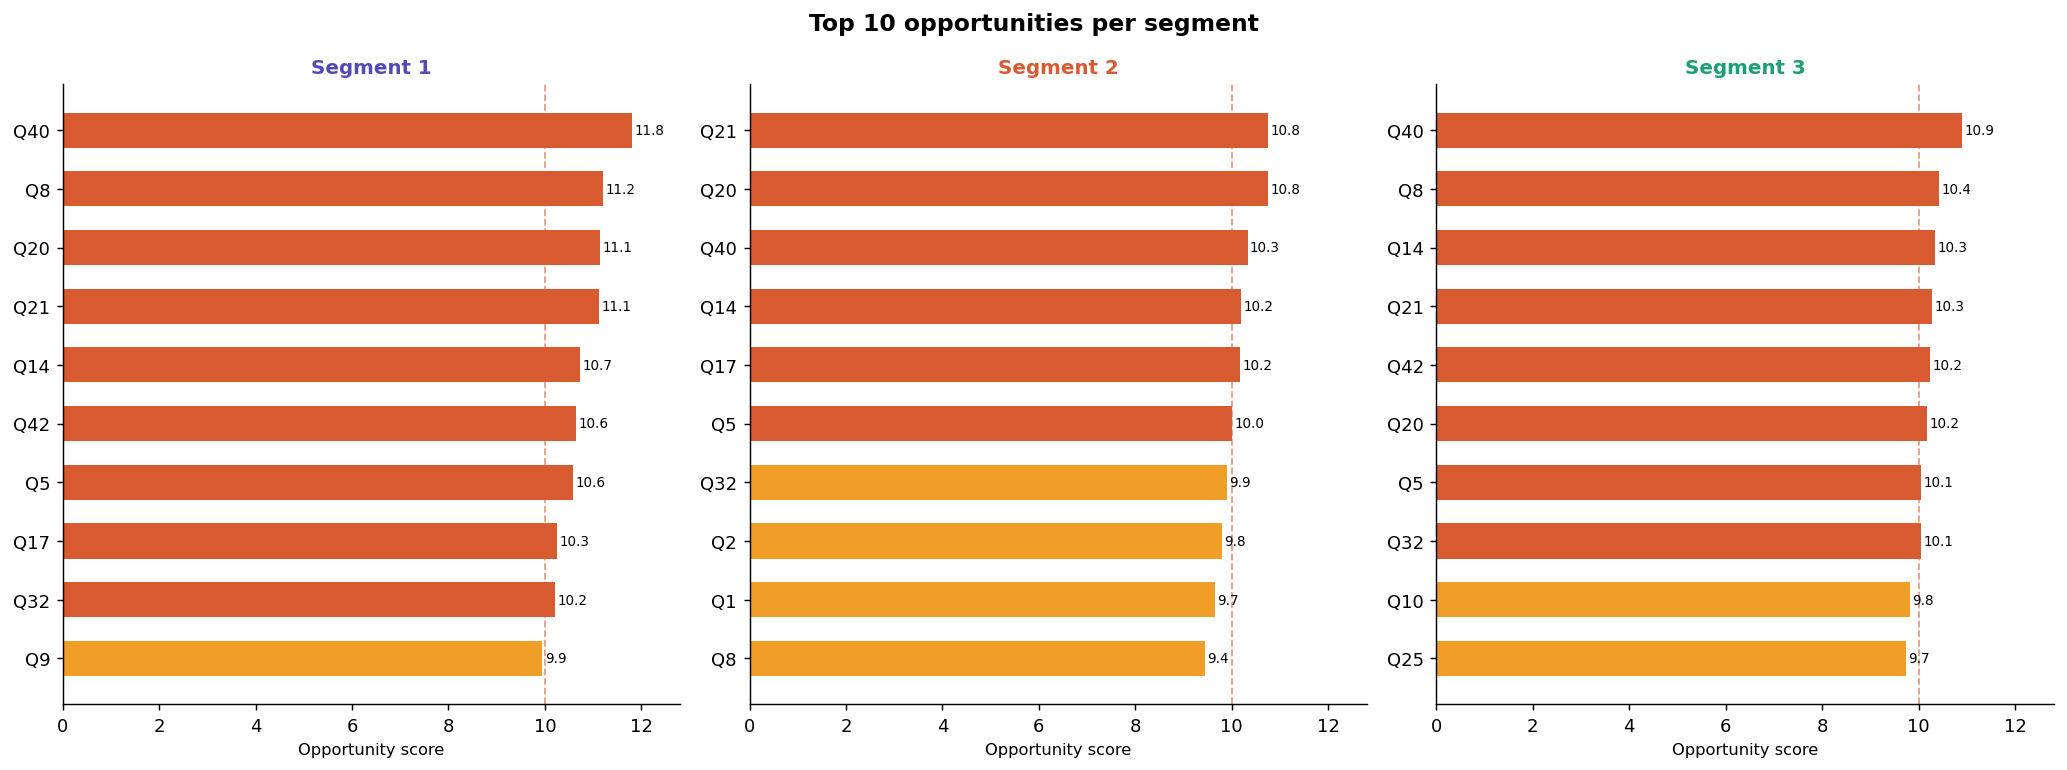

In [10]:
fig, axes = plt.subplots(1, len(segments), figsize=(16, 6))

for i, seg in enumerate(segments):
    seg_opp = opp_seg[opp_seg['segment'] == seg].nlargest(10, 'opportunity_score')
    ax = axes[i]

    bars = ax.barh(seg_opp['outcome'][::-1], seg_opp['opportunity_score'][::-1],
                   color=[COLORS[z] for z in seg_opp['zone'][::-1]], height=0.6)
    ax.axvline(10, color='#D85A30', lw=1, ls='--', alpha=0.6)

    for bar, val in zip(bars, seg_opp['opportunity_score'][::-1]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=7.5)

    ax.set_title(f'Segment {seg}', fontsize=11, fontweight='bold', color=seg_colors[i])
    ax.set_xlabel('Opportunity score', fontsize=9)
    ax.set_xlim(0, opp_seg['opportunity_score'].max() + 1)

fig.suptitle('Top 10 opportunities per segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('top10_per_segment.png', bbox_inches='tight')
plt.show()

## 7. Zone distribution per segment

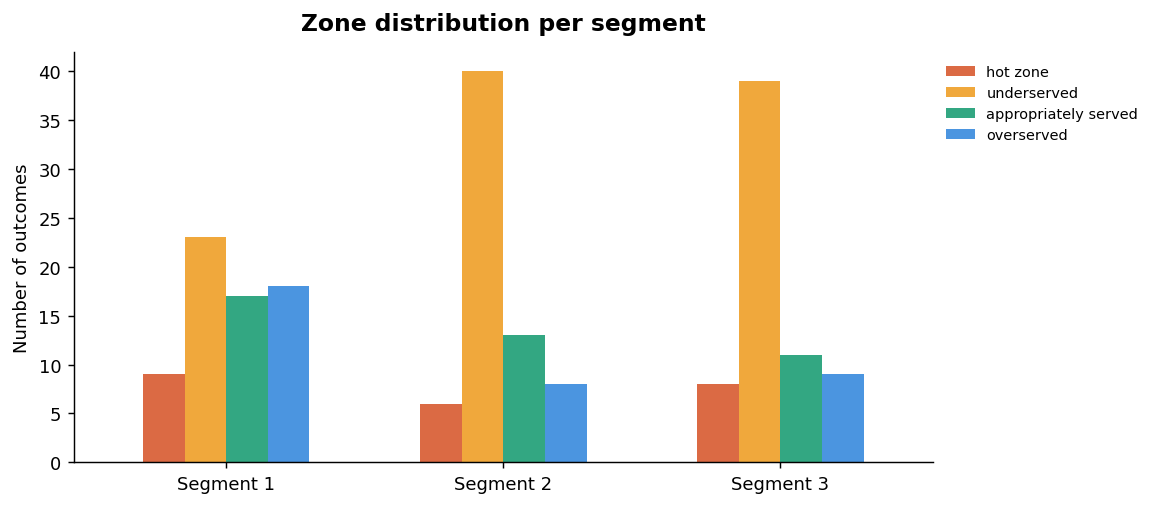

In [11]:
zone_order = ['hot zone', 'underserved', 'appropriately served', 'overserved']
zone_data = []
for seg in segments:
    counts = opp_seg[opp_seg['segment'] == seg]['zone'].value_counts()
    for z in zone_order:
        zone_data.append({'segment': f'Segment {seg}', 'zone': z, 'count': counts.get(z, 0)})

zone_df = pd.DataFrame(zone_data)
pivot = zone_df.pivot(index='segment', columns='zone', values='count')[zone_order]

fig, ax = plt.subplots(figsize=(9, 4))
pivot.plot(kind='bar', ax=ax, color=[COLORS[z] for z in zone_order],
           width=0.6, alpha=0.9)

ax.set_xlabel('')
ax.set_ylabel('Number of outcomes', fontsize=10)
ax.set_title('Zone distribution per segment', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=8, frameon=False, bbox_to_anchor=(1, 1))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('zone_distribution.png', bbox_inches='tight')
plt.show()

## 8. Name your segments
Based on the profiles and opportunity landscapes above, give each segment a name and description.

Use this structure:
- **Name** — a short memorable label (e.g. "The Thriving Kid", "The Struggling Beginner")
- **Who they are** — age, skill, mood pattern
- **What they need most** — top 3 unmet outcomes
- **Design implication** — what the club should do for them

In [12]:
# ── Fill these in after looking at the charts above ──

segment_names = {
    1: "[Your name here]",
    2: "[Your name here]",
    3: "[Your name here]",
}

segment_descriptions = {
    1: "[Describe who this kid is and what they need]",
    2: "[Describe who this kid is and what they need]",
    3: "[Describe who this kid is and what they need]",
}

# Print summary card per segment
for seg in segments:
    seg_df  = df[df['segment'] == seg]
    seg_opp = opp_seg[opp_seg['segment'] == seg]
    top3    = seg_opp.nlargest(3, 'opportunity_score')
    hot     = len(seg_opp[seg_opp['zone'] == 'hot zone'])

    print(f"{'='*50}")
    print(f"SEGMENT {seg} — {segment_names[seg]}")
    print(f"  Kids        : {len(seg_df)} ({len(seg_df)/len(df)*100:.1f}%)")
    print(f"  Avg age     : {seg_df['age'].mean():.1f}")
    print(f"  Stress      : {seg_df['stress_level'].mean():.1f}")
    print(f"  Satisfaction: {seg_df['overall_satisfaction'].mean():.1f}")
    print(f"  Hot zone    : {hot} outcomes")
    print(f"  Top needs   :")
    for _, row in top3.iterrows():
        print(f"    {row.outcome}: {row.opportunity_score:.2f} ({row.zone})")
    print(f"  Description : {segment_descriptions[seg]}")
print('='*50)

SEGMENT 1 — [Your name here]
  Kids        : 368 (37.2%)
  Avg age     : 11.6
  Stress      : 49.6
  Satisfaction: 48.2
  Hot zone    : 9 outcomes
  Top needs   :
    Q40: 11.81 (hot zone)
    Q8: 11.20 (hot zone)
    Q20: 11.14 (hot zone)
  Description : [Describe who this kid is and what they need]
SEGMENT 2 — [Your name here]
  Kids        : 240 (24.3%)
  Avg age     : 10.5
  Stress      : 51.7
  Satisfaction: 48.5
  Hot zone    : 6 outcomes
  Top needs   :
    Q21: 10.75 (hot zone)
    Q20: 10.75 (hot zone)
    Q40: 10.33 (hot zone)
  Description : [Describe who this kid is and what they need]
SEGMENT 3 — [Your name here]
  Kids        : 381 (38.5%)
  Avg age     : 11.0
  Stress      : 41.7
  Satisfaction: 71.2
  Hot zone    : 8 outcomes
  Top needs   :
    Q40: 10.90 (hot zone)
    Q8: 10.42 (hot zone)
    Q14: 10.34 (hot zone)
  Description : [Describe who this kid is and what they need]


## 9. Final summary — what should the club do?
Write your recommendations here based on the analysis.

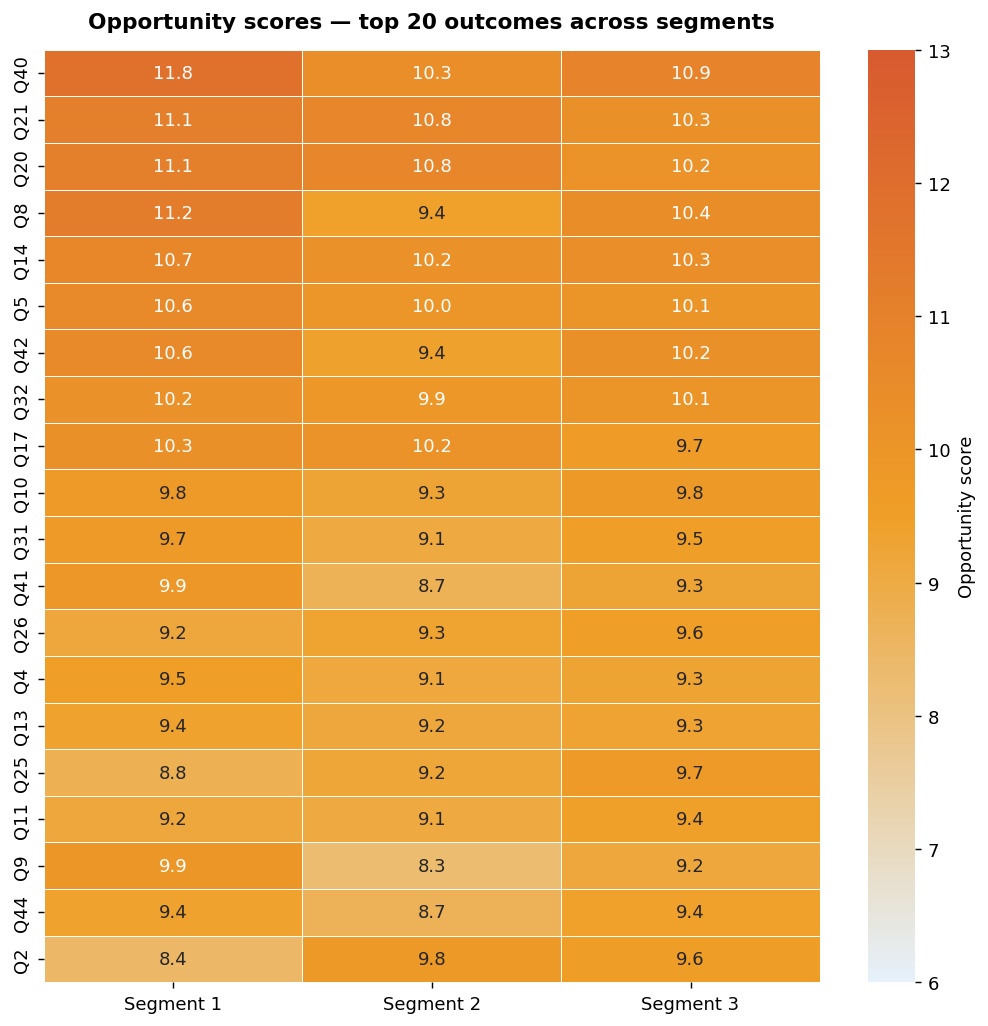

In [13]:
# Heatmap: opportunity scores across all segments for top 20 outcomes
top20 = opp.nlargest(20, 'opportunity_score')['outcome'].tolist()

pivot = opp_seg[opp_seg['outcome'].isin(top20)].pivot(
    index='outcome', columns='segment', values='opportunity_score'
).reindex(top20)
pivot.columns = [f'Segment {s}' for s in pivot.columns]

fig, ax = plt.subplots(figsize=(8, 8))
cmap = LinearSegmentedColormap.from_list('opp', ['#E6F1FB', '#EF9F27', '#D85A30'])
sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, linewidths=0.4,
            ax=ax, cbar_kws={'label': 'Opportunity score'}, vmin=6, vmax=13)

ax.set_title('Opportunity scores — top 20 outcomes across segments',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('heatmap_segments.png', bbox_inches='tight')
plt.show()